In [ ]:
"""
DziriBERT Multi-Label Text Classification - Sentiment Analysis Model
=====================================================================
This notebook implements multi-label classification for Algerian dialect
social media comments using DziriBERT fine-tuned for sentiment analysis.

Author: Boumaout Farah
Dataset: Restaurant reviews in Algerian dialect
Labels: 25 multi-label targets (food, service, place, delivery, price, treatment × sentiment)
"""

# ============================================================================
# 1. SETUP & INSTALLATION
# ============================================================================

!pip install -q transformers datasets scikit-learn pandas matplotlib seaborn torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    hamming_loss,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    multilabel_confusion_matrix
)
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from torch.optim import AdamW # Corrected import for AdamW
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Détection du device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



Using device: cuda


In [ ]:
# ============================================================================
# 2. LOAD DATA
# ============================================================================

# Upload your CSV file in Colab
df = pd.read_csv("/kaggle/input/finaldataset/MultilabelFinalDataset.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (23928, 32)

First few rows:


,final_id,comment_text,comment_id,platform,source_name,date,likesCount,food_appreciation,food_complaint,food_recommendation,...,delivery_inquiry,price_appreciation,price_complaint,price_recommendation,price_inquiry,treatment_appreciation,treatment_complaint,treatment_recommendation,treatment_inquiry,out_of_scope
0,623264.0,le serveur a un bon sourire [APPRECIATION],68416.0,tiktok,@restaurantvillariviera,2026-01-02T21:55:54.263697,1.0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,230050.0,On a été pour un dîner on a pris un mélange de...,5087.0,Google Maps,قصبة اسطنبول,2025-08-27T13:28:34.862Z,0.0,1,0,0,...,0,0,1,0,0,1,0,0,0,0
2,885412.0,هدو هما لعايشين لاسف يزيدو للبحر سعيدة زوالي ...,57560.0,tiktok,@_le216_,2026-01-02T21:17:27.096146,5.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,492221.0,والله يا نزيهة تعاوديها تخرجي برا [APPRECIATION],41438.0,tiktok,@street_food,2026-01-02T19:55:45.735937,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,230078.0,Je préfère payer cher chez Weld bladi que aill...,35598.0,tiktok,@sinai,2026-01-02T19:28:17.247621,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1



EXPLORATORY DATA ANALYSIS

Total samples: 23928
Total labels: 25

Missing values in comment_text: 1
Samples after removing NaN: 23927

Text Statistics:
Average length: 70.69 characters
Average words: 12.59
Max length: 2194 characters
Min length: 2 characters

Sentiment Type Distribution:
Appreciation: 14932 (62.41%)
Complaint: 7925 (33.12%)
Recommendation: 447 (1.87%)
Inquiry: 3287 (13.74%)

Category Distribution:
Food: 8001 (33.44%)
Service: 3106 (12.98%)
Place: 6810 (28.46%)
Delivery: 807 (3.37%)
Price: 4336 (18.12%)
Treatment: 3531 (14.76%)

Label                          Count      Percentage
--------------------------------------------------
out_of_scope                   9107       38.06%
food_appreciation              4934       20.62%
place_appreciation             3889       16.25%
treatment_appreciation         2647       11.06%
food_complaint                 2536       10.60%
price_complaint                2385       9.97%
service_appreciation           2088       8.73%
pla

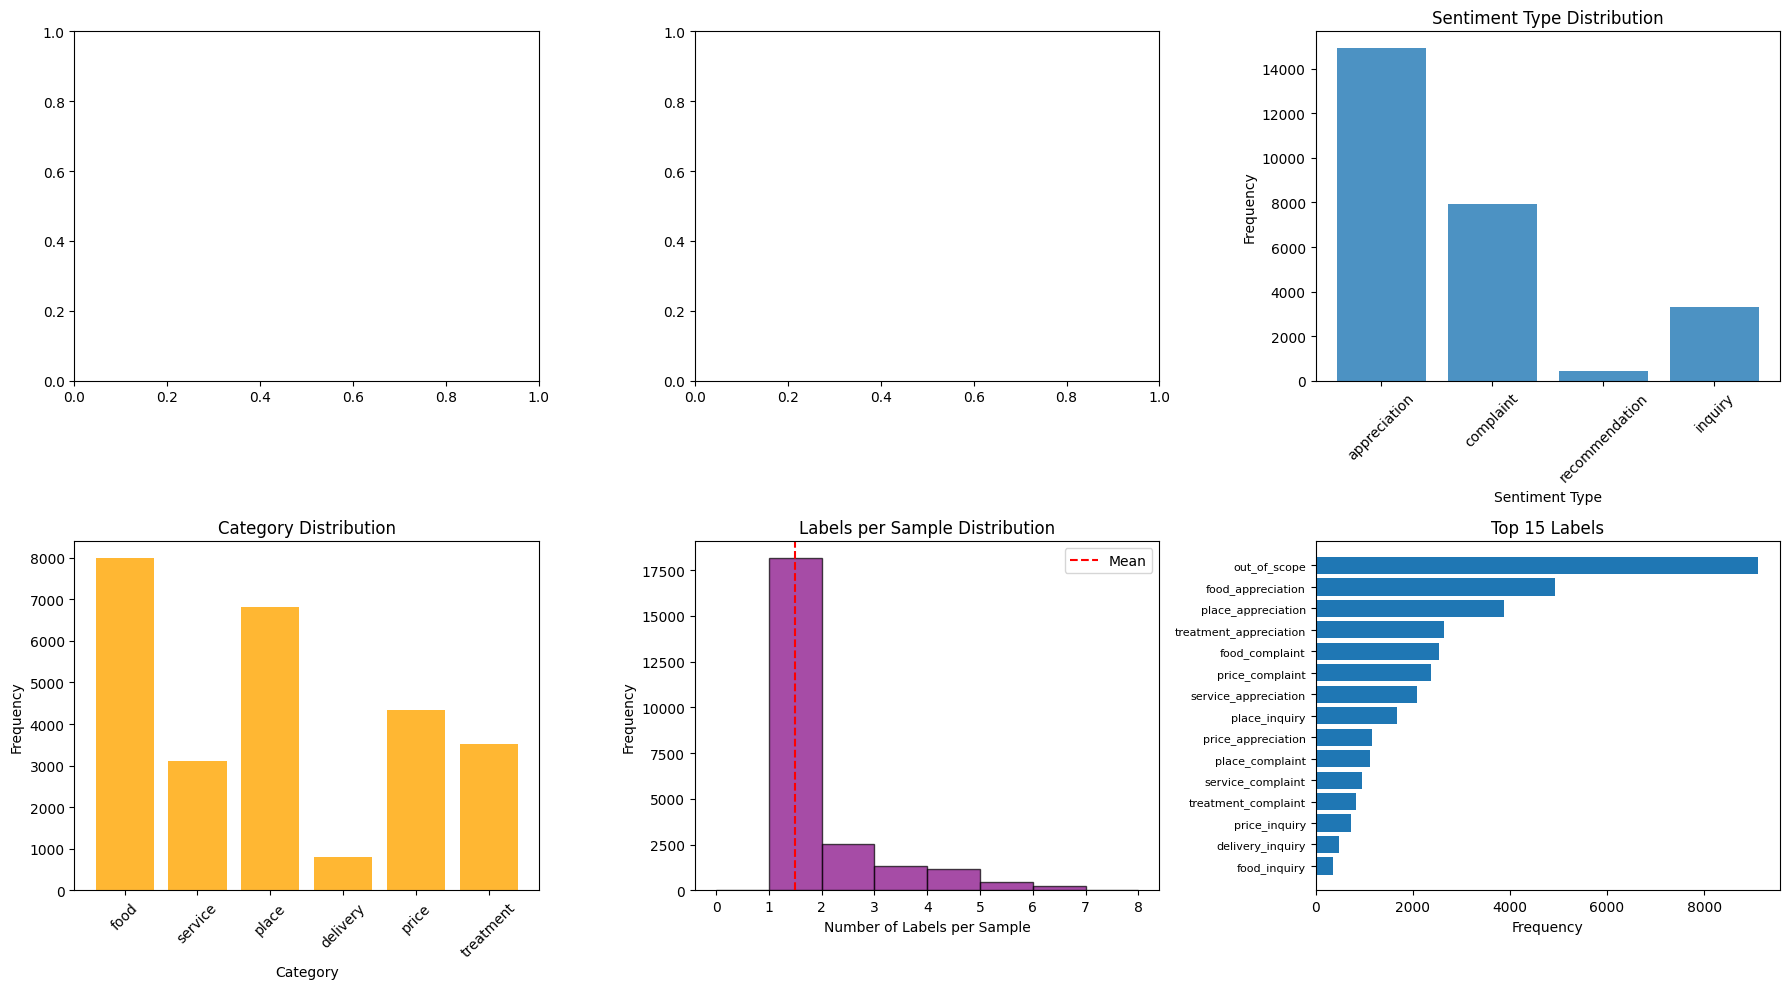


Label Statistics:
Samples with 0 labels: 0
Samples with 1 label: 18183
Samples with 2+ labels: 5744
Average labels per sample: 1.49
Max labels per sample: 7


In [ ]:

# ============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# Define label columns
original_label_columns  = [
    'food_appreciation', 'food_complaint', 'food_recommendation', 'food_inquiry',
    'service_appreciation', 'service_complaint', 'service_recommendation', 'service_inquiry',
    'place_appreciation', 'place_complaint', 'place_recommendation', 'place_inquiry',
    'delivery_appreciation', 'delivery_complaint', 'delivery_recommendation', 'delivery_inquiry',
    'price_appreciation', 'price_complaint', 'price_recommendation', 'price_inquiry',
    'treatment_appreciation', 'treatment_complaint', 'treatment_recommendation', 'treatment_inquiry',
    'out_of_scope'
]

# Basic statistics
print(f"\nTotal samples: {len(df)}")
print(f"Total labels: {len(original_label_columns)}")
print(f"\nMissing values in comment_text: {df['comment_text'].isna().sum()}")

# Remove rows with missing text
df = df.dropna(subset=['comment_text'])
df = df.reset_index(drop=True)
print(f"Samples after removing NaN: {len(df)}")

# Text length analysis
df['text_length'] = df['comment_text'].str.len()
df['word_count'] = df['comment_text'].str.split().str.len()

print(f"\nText Statistics:")
print(f"Average length: {df['text_length'].mean():.2f} characters")
print(f"Average words: {df['word_count'].mean():.2f}")
print(f"Max length: {df['text_length'].max()} characters")
print(f"Min length: {df['text_length'].min()} characters")

# Sentiment analysis - aggregate sentiment types
sentiment_types = ['appreciation', 'complaint', 'recommendation', 'inquiry']
sentiment_counts = {}

for sent_type in sentiment_types:
    cols = [col for col in original_label_columns if sent_type in col]
    sentiment_counts[sent_type] = df[cols].sum().sum()

print(f"\nSentiment Type Distribution:")
for sent_type, count in sentiment_counts.items():
    print(f"{sent_type.capitalize()}: {count} ({count/len(df)*100:.2f}%)")

# Category analysis
categories = ['food', 'service', 'place', 'delivery', 'price', 'treatment']
category_counts = {}

for cat in categories:
    cols = [col for col in original_label_columns if col.startswith(cat)]
    category_counts[cat] = df[cols].sum().sum()

print(f"\nCategory Distribution:")
for cat, count in category_counts.items():
    print(f"{cat.capitalize()}: {count} ({count/len(df)*100:.2f}%)")

# Label distribution
print(f"\n{'Label':<30} {'Count':<10} {'Percentage':<10}")
print("-" * 50)

label_data = []
for label in original_label_columns:
    count = df[label].sum()
    pct = (count / len(df)) * 100
    label_data.append({'label': label, 'count': count, 'percentage': pct})

# Sort label_data by count in descending order
label_data_sorted = sorted(label_data, key=lambda x: x['count'], reverse=True)

for item in label_data_sorted:
    print(f"{item['label']:<30} {item['count']:<10} {item['percentage']:.2f}%")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))


# Sentiment type distribution
axes[0, 2].bar(sentiment_counts.keys(), sentiment_counts.values(), alpha=0.8)
axes[0, 2].set_xlabel('Sentiment Type')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Sentiment Type Distribution')
axes[0, 2].tick_params(axis='x', rotation=45)

# Category distribution
axes[1, 0].bar(category_counts.keys(), category_counts.values(), alpha=0.8, color='orange')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Category Distribution')
axes[1, 0].tick_params(axis='x', rotation=45)

# Labels per sample
labels_per_sample = df[original_label_columns].sum(axis=1)
axes[1, 1].hist(labels_per_sample, bins=range(labels_per_sample.max() + 2),
                edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Number of Labels per Sample')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Labels per Sample Distribution')
axes[1, 1].axvline(labels_per_sample.mean(), color='red', linestyle='--', label='Mean')
axes[1, 1].legend()

# Top 15 labels
label_counts = df[original_label_columns].sum().sort_values(ascending=False).head(15)
axes[1, 2].barh(range(len(label_counts)), label_counts.values)
axes[1, 2].set_yticks(range(len(label_counts)))
axes[1, 2].set_yticklabels(label_counts.index, fontsize=8)
axes[1, 2].set_xlabel('Frequency')
axes[1, 2].set_title('Top 15 Labels')
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nLabel Statistics:")
print(f"Samples with 0 labels: {(labels_per_sample == 0).sum()}")
print(f"Samples with 1 label: {(labels_per_sample == 1).sum()}")
print(f"Samples with 2+ labels: {(labels_per_sample >= 2).sum()}")
print(f"Average labels per sample: {labels_per_sample.mean():.2f}")
print(f"Max labels per sample: {labels_per_sample.max()}")


Balancing dataset

In [ ]:
labels_to_remove = [
    "delivery_recommendation",   # 10
    "service_recommendation",    # 24
    "treatment_inquiry",         # 24
    "treatment_recommendation", # 35
    "service_inquiry"             #34
]

label_columns = [c for c in original_label_columns if c not in labels_to_remove]

print("Final number of labels:", len(label_columns))
print(label_columns)


# Columns to keep
columns_to_keep = ["comment_text"] + label_columns

# Drop everything else
df_clean = df[columns_to_keep].copy()

print("Remaining columns:")
print(df_clean.columns.tolist())


# Compute number of labels per sample
df_clean["num_labels"] = df_clean[label_columns].sum(axis=1)

# Keep only samples with at least 1 label
df_clean = df_clean[df_clean["num_labels"] > 0].reset_index(drop=True)

print("Samples after cleaning:", len(df_clean))


df_clean = df_clean.drop(columns=["num_labels"])


label_counts = df_clean[label_columns].sum().sort_values(ascending=False)

print("\nNew label distribution:")
for label, count in label_counts.items():
    pct = 100 * count / len(df_clean)
    print(f"{label:25s} {int(count):6d}  ({pct:.2f}%)")

df_clean.head(5)



Final number of labels: 20
['food_appreciation', 'food_complaint', 'food_recommendation', 'food_inquiry', 'service_appreciation', 'service_complaint', 'place_appreciation', 'place_complaint', 'place_recommendation', 'place_inquiry', 'delivery_appreciation', 'delivery_complaint', 'delivery_inquiry', 'price_appreciation', 'price_complaint', 'price_recommendation', 'price_inquiry', 'treatment_appreciation', 'treatment_complaint', 'out_of_scope']
Remaining columns:
['comment_text', 'food_appreciation', 'food_complaint', 'food_recommendation', 'food_inquiry', 'service_appreciation', 'service_complaint', 'place_appreciation', 'place_complaint', 'place_recommendation', 'place_inquiry', 'delivery_appreciation', 'delivery_complaint', 'delivery_inquiry', 'price_appreciation', 'price_complaint', 'price_recommendation', 'price_inquiry', 'treatment_appreciation', 'treatment_complaint', 'out_of_scope']
Samples after cleaning: 23857

New label distribution:
out_of_scope                9107  (38.17%)


,comment_text,food_appreciation,food_complaint,food_recommendation,food_inquiry,service_appreciation,service_complaint,place_appreciation,place_complaint,place_recommendation,...,delivery_appreciation,delivery_complaint,delivery_inquiry,price_appreciation,price_complaint,price_recommendation,price_inquiry,treatment_appreciation,treatment_complaint,out_of_scope
0,le serveur a un bon sourire [APPRECIATION],0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,On a été pour un dîner on a pris un mélange de...,1,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0
2,هدو هما لعايشين لاسف يزيدو للبحر سعيدة زوالي ...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,والله يا نزيهة تعاوديها تخرجي برا [APPRECIATION],0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,Je préfère payer cher chez Weld bladi que aill...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


over/undersampling

Oversampled delivery_inquiry: added 567 samples
Oversampled food_inquiry: added 594 samples
Oversampled delivery_appreciation: added 590 samples
Oversampled food_recommendation: added 365 samples
Oversampled place_recommendation: added 322 samples
Oversampled delivery_complaint: added 329 samples
Oversampled price_recommendation: added 205 samples

Resampled dataset shape: (23186, 21)

New label distribution after resampling:

out_of_scope                5464  (23.57%)
food_appreciation           4934  (21.28%)
place_appreciation          3889  (16.77%)
treatment_appreciation      2647  (11.42%)
food_complaint              2536  (10.94%)
price_complaint             2385  (10.29%)
service_appreciation        2088  (9.01%)
place_inquiry               1679  (7.24%)
price_appreciation          1154  (4.98%)
place_complaint             1116  (4.81%)
delivery_inquiry            1041  (4.49%)
service_complaint            960  (4.14%)
food_inquiry                 944  (4.07%)
treatment_complai

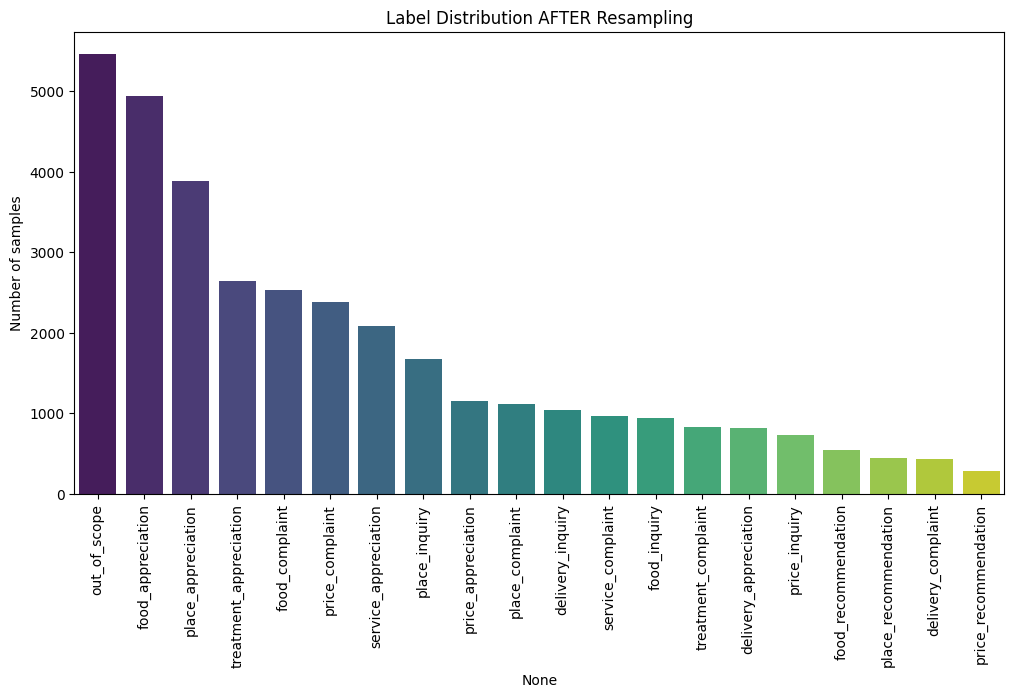

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_resampled = df_clean.copy()

# List of all label columns
label_columns = [col for col in df_resampled.columns if col != 'comment_text']

# Define target counts for rare labels
target_counts = {
    'delivery_inquiry': 1000,
    'food_inquiry': 900,
    'delivery_appreciation': 600,
    'food_recommendation': 500,
    'place_recommendation': 400,
    'delivery_complaint': 350,
    'price_recommendation': 250,
}

# --- Oversample rare labels (only samples where THIS label is 1 and all others are 0) ---
for label, target in target_counts.items():
    other_labels = [l for l in label_columns if l != label]
    # Corrected: all other labels must be 0
    df_label_only = df_resampled[(df_resampled[label] == 1) & (df_resampled[other_labels].sum(axis=1) == 0)]

    current_count = len(df_label_only)
    if current_count == 0:
        print(f"No pure samples found for {label}, skipping...")
        continue

    n_to_add = target - current_count
    if n_to_add <= 0:
        print(f"{label} already has {current_count} samples, target {target}, skipping...")
        continue

    # Randomly duplicate pure samples
    df_oversampled = df_label_only.sample(n=n_to_add, replace=True, random_state=42)
    df_resampled = pd.concat([df_resampled, df_oversampled], axis=0)
    print(f"Oversampled {label}: added {n_to_add} samples")

# --- Undersample dominant label: out_of_scope ---
dominant_label = 'out_of_scope'
keep_fraction = 0.6
df_dominant = df_resampled[df_resampled[dominant_label] == 1]
df_non_dominant = df_resampled[df_resampled[dominant_label] == 0]
df_dominant_downsampled = df_dominant.sample(frac=keep_fraction, random_state=42)
df_resampled = pd.concat([df_non_dominant, df_dominant_downsampled], axis=0)

# Shuffle final dataset
df_resampled = df_resampled.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("\nResampled dataset shape:", df_resampled.shape)

# --- Compute label counts and percentages ---
total_samples = len(df_resampled)
label_counts = df_resampled[label_columns].sum().sort_values(ascending=False)

print("\nNew label distribution after resampling:\n")
for label, count in label_counts.items():
    pct = 100 * count / total_samples
    print(f"{label:25s} {int(count):6d}  ({pct:.2f}%)")

# --- Visualization ---
plt.figure(figsize=(12,6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.xticks(rotation=90)
plt.ylabel("Number of samples")
plt.title("Label Distribution AFTER Resampling")
plt.show()


In [ ]:

num_positives = torch.tensor(df_resampled[label_columns].sum().values, dtype=torch.float)
num_negatives = len(df_resampled) - num_positives
pos_weight = num_negatives / num_positives
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))


In [ ]:
# ============================================================================
# 4. DATA PREPARATION
# ============================================================================
SEED = 42
print("\n" + "="*80)
print("DATA PREPARATION")
print("="*80)

# Prepare features and labels
X = df_resampled['comment_text'].values
y = df_resampled[label_columns].values.astype(np.float32)

# Train-validation-test split (70-15-15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=None
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")



DATA PREPARATION
Training samples: 16230
Validation samples: 3478
Test samples: 3478


In [ ]:

# ============================================================================
# 5. TOKENIZATION
# ============================================================================

print("\n" + "="*80)
print("TOKENIZATION")
print("="*80)

# Load DziriBERT Sentiment tokenizer
MODEL_NAME = "alger-ia/dziribert_sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Loaded tokenizer: {MODEL_NAME}")
print("This model is pre-trained for sentiment analysis on Algerian dialect")

# Tokenization parameters
MAX_LENGTH = 128
BATCH_SIZE = 16

# Custom Dataset class
class MultiLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.float32)
        }

# Create datasets
train_dataset = MultiLabelDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset = MultiLabelDataset(X_val, y_val, tokenizer, MAX_LENGTH)
test_dataset = MultiLabelDataset(X_test, y_test, tokenizer, MAX_LENGTH)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")



TOKENIZATION


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/810 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Loaded tokenizer: alger-ia/dziribert_sentiment
This model is pre-trained for sentiment analysis on Algerian dialect
Training batches: 1015
Validation batches: 218
Test batches: 218


In [ ]:
from transformers import AutoModel

# ============================================================================
# 6. MODEL DEFINITION
# ============================================================================

print("\n" + "="*80)
print("MODEL DEFINITION")
print("="*80)

class DziriBERTSentimentMultiLabel(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.3):
        super().__init__()
        # Load the sentiment model as base
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Use CLS token representation
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits




MODEL DEFINITION


In [ ]:
# ============================================================================
# 7. TRAINING FUNCTIONS
# ============================================================================

def train_epoch(model, dataloader, optimizer, scheduler, device, criterion):
    model.train()
    total_loss = 0

    progress_bar = tqdm(dataloader, desc="Training")
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    return total_loss / len(dataloader)

def evaluate(model, dataloader, device, criterion):
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.sigmoid(logits).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())

    predictions = np.array(predictions)
    true_labels = np.array(true_labels)

    return total_loss / len(dataloader), predictions, true_labels

def calculate_metrics(y_true, y_pred, threshold=0.5):
    y_pred_binary = (y_pred >= threshold).astype(int)

    metrics = {
        'hamming_loss': hamming_loss(y_true, y_pred_binary),
        'accuracy': accuracy_score(y_true, y_pred_binary),
        'macro_f1': f1_score(y_true, y_pred_binary, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred_binary, average='weighted', zero_division=0),
        'macro_precision': precision_score(y_true, y_pred_binary, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred_binary, average='macro', zero_division=0)
    }

    return metrics, y_pred_binary

# Initialize model
num_labels = len(label_columns)
model_frozen = DziriBERTSentimentMultiLabel(MODEL_NAME, num_labels).to(device)
print(model_frozen)


2026-01-23 22:49:15.708540: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769208555.878497      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769208555.929995      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769208556.344897      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769208556.344941      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769208556.344944      55 computation_placer.cc:177] computation placer alr

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

DziriBERTSentimentMultiLabel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-

In [ ]:
from transformers import get_linear_schedule_with_warmup

# ============================================================================
# 9. TRAINING - UNFROZEN BERT
# ============================================================================

print("\n" + "="*80)
print("TRAINING WITH UNFROZEN SENTIMENT MODEL (Full Fine-tuning)")
print("="*80)

# Initialize new model
model_unfrozen = DziriBERTSentimentMultiLabel(MODEL_NAME, num_labels).to(device)

# All parameters are trainable
trainable_params = sum(p.numel() for p in model_unfrozen.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_unfrozen.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

# Training configuration
EPOCHS_UNFROZEN = 5
LEARNING_RATE_UNFROZEN = 2e-5

optimizer_unfrozen = AdamW(model_unfrozen.parameters(), lr=LEARNING_RATE_UNFROZEN)

total_steps_unfrozen = len(train_loader) * EPOCHS_UNFROZEN
scheduler_unfrozen = get_linear_schedule_with_warmup(
    optimizer_unfrozen,
    num_warmup_steps=int(0.1 * total_steps_unfrozen),
    num_training_steps=total_steps_unfrozen
)

# Training loop
train_losses_unfrozen = []
val_losses_unfrozen = []
best_val_f1_unfrozen = 0
best_model_unfrozen = None

print("\nStarting fine-tuning (unfrozen sentiment model)...")
for epoch in range(EPOCHS_UNFROZEN):
    print(f"\nEpoch {epoch + 1}/{EPOCHS_UNFROZEN}")

    train_loss = train_epoch(model_unfrozen, train_loader, optimizer_unfrozen,
                            scheduler_unfrozen, device, criterion)
    val_loss, val_preds, val_true = evaluate(model_unfrozen, val_loader, device, criterion)

    metrics, _ = calculate_metrics(val_true, val_preds)

    train_losses_unfrozen.append(train_loss)
    val_losses_unfrozen.append(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {metrics['accuracy']:.4f}")
    print(f"Val Macro F1: {metrics['macro_f1']:.4f}")
    print(f"Val Hamming Loss: {metrics['hamming_loss']:.4f}")

    if metrics['macro_f1'] > best_val_f1_unfrozen:
        best_val_f1_unfrozen = metrics['macro_f1']
        best_model_unfrozen = model_unfrozen.state_dict().copy()
        print("✓ New best model saved!")

# Load best model and evaluate on test set
model_unfrozen.load_state_dict(best_model_unfrozen)
test_loss_unfrozen, test_preds_unfrozen, test_true = evaluate(model_unfrozen, test_loader, device, criterion)
test_metrics_unfrozen, test_preds_binary_unfrozen = calculate_metrics(test_true, test_preds_unfrozen)

print("\n" + "="*80)
print("UNFROZEN SENTIMENT MODEL - TEST SET RESULTS")
print("="*80)
for metric, value in test_metrics_unfrozen.items():
    print(f"{metric}: {value:.4f}")



TRAINING WITH UNFROZEN SENTIMENT MODEL (Full Fine-tuning)
Trainable parameters: 124,456,724 / 124,456,724

Starting fine-tuning (unfrozen sentiment model)...

Epoch 1/5


Evaluating: 100%|██████████| 218/218 [00:27<00:00,  7.80it/s]


Train Loss: 0.8123
Val Loss: 0.4804
Val Accuracy: 0.1952
Val Macro F1: 0.5124
Val Hamming Loss: 0.1094
✓ New best model saved!

Epoch 2/5


Evaluating: 100%|██████████| 218/218 [00:27<00:00,  7.81it/s]


Train Loss: 0.4000
Val Loss: 0.4275
Val Accuracy: 0.3755
Val Macro F1: 0.6430
Val Hamming Loss: 0.0683
✓ New best model saved!

Epoch 3/5


...

Train Loss: 0.1949
Val Loss: 0.5008
Val Accuracy: 0.5035
Val Macro F1: 0.7163
Val Hamming Loss: 0.0517
✓ New best model saved!

Epoch 5/5


Evaluating: 100%|██████████| 218/218 [00:28<00:00,  7.78it/s]


Train Loss: 0.1534
Val Loss: 0.5307
Val Accuracy: 0.5290
Val Macro F1: 0.7300
Val Hamming Loss: 0.0487
✓ New best model saved!


Evaluating: 100%|██████████| 218/218 [00:27<00:00,  7.81it/s]



UNFROZEN SENTIMENT MODEL - TEST SET RESULTS
hamming_loss: 0.0465
accuracy: 0.5377
macro_f1: 0.7362
weighted_f1: 0.7366
macro_precision: 0.6604
macro_recall: 0.8464


In [ ]:
torch.save(best_model_unfrozen, "best_dziribert_sentimentversion2.pth")



PER-LABEL CLASSIFICATION REPORT (UNFROZEN SENTIMENT MODEL)
                        precision    recall  f1-score   support

     food_appreciation       0.72      0.87      0.79       725
        food_complaint       0.64      0.81      0.71       404
   food_recommendation       0.74      0.93      0.83        84
          food_inquiry       0.77      0.99      0.87       138
  service_appreciation       0.50      0.81      0.62       286
     service_complaint       0.61      0.85      0.71       138
    place_appreciation       0.61      0.86      0.71       572
       place_complaint       0.28      0.72      0.41       139
  place_recommendation       0.78      0.83      0.81        60
         place_inquiry       0.82      0.90      0.86       266
 delivery_appreciation       0.67      0.79      0.73       121
    delivery_complaint       0.80      0.86      0.83        57
      delivery_inquiry       0.97      0.96      0.97       178
    price_appreciation       0.50      0.69

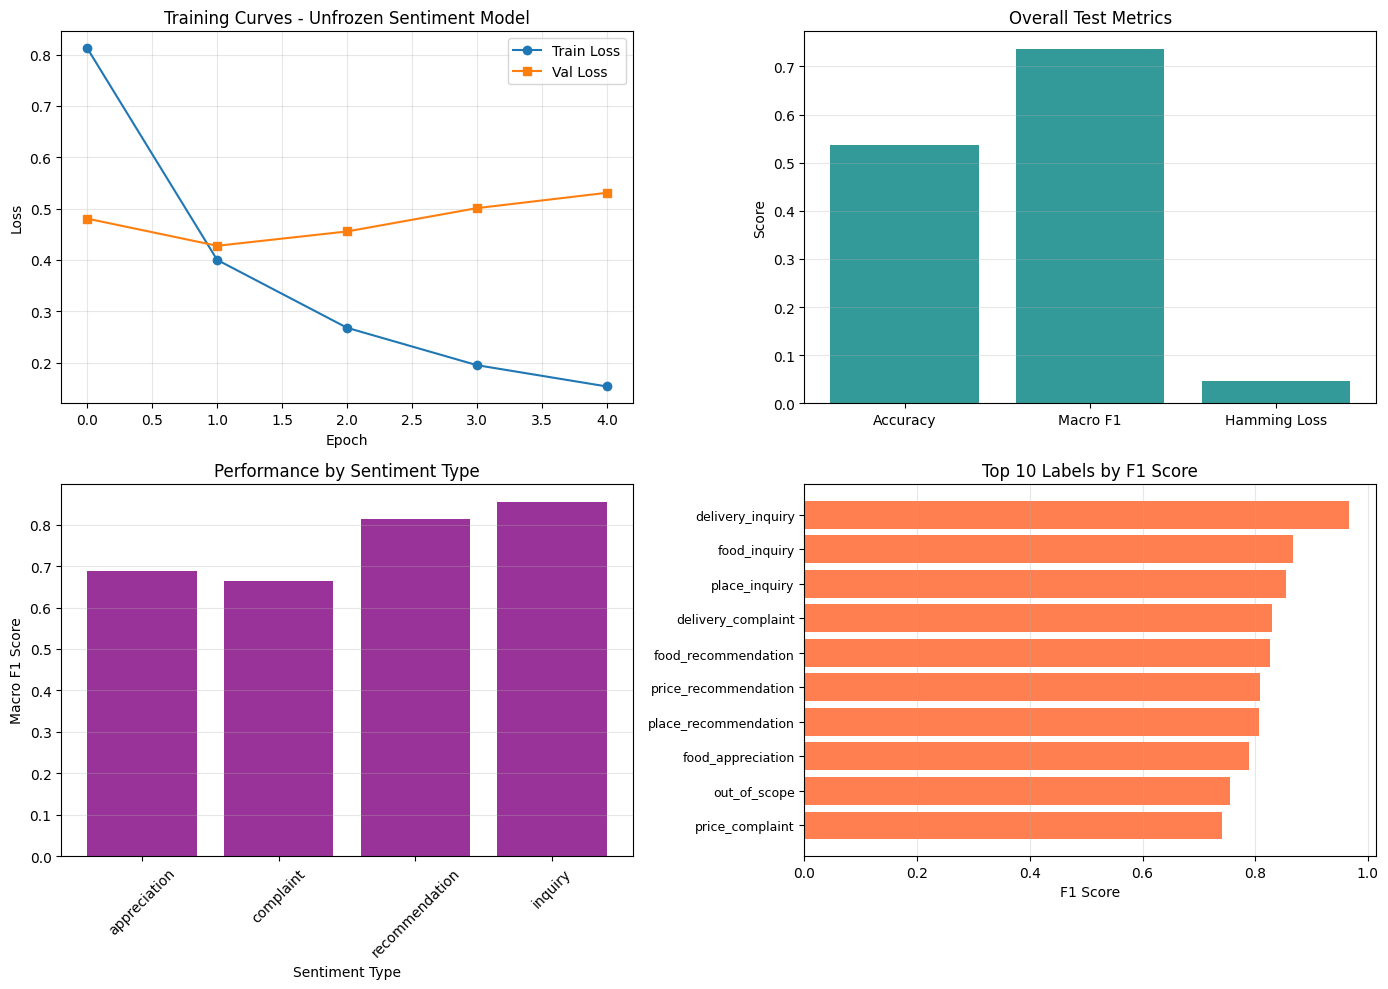

In [ ]:
# ============================================================================
# 10. DETAILED EVALUATION - UNFROZEN ONLY
# ============================================================================

print("\n" + "="*80)
print("PER-LABEL CLASSIFICATION REPORT (UNFROZEN SENTIMENT MODEL)")
print("="*80)

print(classification_report(
    test_true,
    test_preds_binary_unfrozen,
    target_names=label_columns,
    zero_division=0
))

# Sentiment-specific analysis
print("\n" + "="*80)
print("SENTIMENT-SPECIFIC PERFORMANCE")
print("="*80)

sentiment_groups = {
    'appreciation': [i for i, col in enumerate(label_columns) if 'appreciation' in col],
    'complaint': [i for i, col in enumerate(label_columns) if 'complaint' in col],
    'recommendation': [i for i, col in enumerate(label_columns) if 'recommendation' in col],
    'inquiry': [i for i, col in enumerate(label_columns) if 'inquiry' in col]
}

for sentiment, indices in sentiment_groups.items():
    if len(indices) > 0:
        sentiment_true = test_true[:, indices]
        sentiment_pred = test_preds_binary_unfrozen[:, indices]

        f1 = f1_score(sentiment_true, sentiment_pred, average='macro', zero_division=0)
        precision = precision_score(sentiment_true, sentiment_pred, average='macro', zero_division=0)
        recall = recall_score(sentiment_true, sentiment_pred, average='macro', zero_division=0)

        print(f"\n{sentiment.upper()}:")
        print(f"  Macro F1: {f1:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training curves - Unfrozen
axes[0, 0].plot(train_losses_unfrozen, label='Train Loss', marker='o')
axes[0, 0].plot(val_losses_unfrozen, label='Val Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Curves - Unfrozen Sentiment Model')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Metrics summary
metrics_names = ['Accuracy', 'Macro F1', 'Hamming Loss']
metrics_unfrozen = [test_metrics_unfrozen['accuracy'],
                     test_metrics_unfrozen['macro_f1'],
                     test_metrics_unfrozen['hamming_loss']]

axes[0, 1].bar(metrics_names, metrics_unfrozen, color='teal', alpha=0.8)
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Overall Test Metrics')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Per-sentiment F1 scores
sentiment_f1s = []
sentiment_names = []
for sentiment, indices in sentiment_groups.items():
    if len(indices) > 0:
        sentiment_true = test_true[:, indices]
        sentiment_pred = test_preds_binary_unfrozen[:, indices]
        f1 = f1_score(sentiment_true, sentiment_pred, average='macro', zero_division=0)
        sentiment_f1s.append(f1)
        sentiment_names.append(sentiment)

axes[1, 0].bar(sentiment_names, sentiment_f1s, alpha=0.8, color='purple')
axes[1, 0].set_xlabel('Sentiment Type')
axes[1, 0].set_ylabel('Macro F1 Score')
axes[1, 0].set_title('Performance by Sentiment Type')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Per-label F1 scores
label_f1_scores = [f1_score(test_true[:, i], test_preds_binary_unfrozen[:, i], zero_division=0)
                   for i in range(len(label_columns))]

top_10_indices = np.argsort(label_f1_scores)[-10:]
axes[1, 1].barh(range(10), [label_f1_scores[i] for i in top_10_indices], color='coral')
axes[1, 1].set_yticks(range(10))
axes[1, 1].set_yticklabels([label_columns[i] for i in top_10_indices], fontsize=9)
axes[1, 1].set_xlabel('F1 Score')
axes[1, 1].set_title('Top 10 Labels by F1 Score')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------
# 1️⃣ Prepare your list of comments

comments = [
    "Sympa restaurant, la viande est bonne, service sympa, seul truc que j’ai pas aimé l’accompagnement, une portion de viande avec seulement un tas de frites, faut faire un effort Mr Hicham.",
    "Un restaurant sympa et convivial où l'on peut déjeuner ou dîner entre amis ou en famille dans une bonne ambiance. On a le choix entre les plats du jour ou bien la carte qui propose des plats très variés. Un peu déçu par les noisettes d'agneau mais bonne soirée dans l'ensemble. Les desserts sont aussi à améliorer. Les serveurs sont aimables et à l'écoute. Boissons soft ou alcoolisées au choix. Parking extérieur dans la rue.",
    "Bel endroit, juste changer de type de musique.",
    "Bonne organisation, problème de stationnement. Burger généreux, manque de saveurs.",
    "مدة الانتظار كبيرة تفوق 30 دقيقة كمية اللحم في الخبز قليلة او عادية بنة عادي لا اكثر عمال استقبال شباب ويتكلموا بزاف مع بعضهم ويستعملو هواتف اثناء العمل ولا يبالون في استقبال الزبائن نظافة موجودة موقف سيارة صعب او لا يوجد ثمن لا يناسب مع نوعية الاكل",
    "Restaurant plutôt moyen. Les serveurs ne sont pas très agréables, limite ils nous ont foutu dehors. L'attente était lente. Les prix sont bons. La kunafa était bonne et le café est à déconseiller.",
    "J ai aimé beaucoup le burger triple viande hachée. Je déconseille le poutine, soit viande soit poulet, il ne mérite pas 550 DA, c est un gratin plein de frites. Le burger simple est nul alors go big go home. Pour les gens qui aiment la bouffe qualité et quantité le tacos steak à 800 DA est très bon, demandé sans frites, un grand tacos de 950 grammes peut suffire pour 2 personnes.",
    "Viré le caissier, rien qu'à voir sa gueule on perd l'appétit. Les gens de salle sont très bien. Les sandwichs sont surcotés. Et ce foutu caissier qui n a rien à faire là-bas. Plus jamais.",
    "Lieu sympa cosy et terrasse sympa. Je déconseille les gaufres et crêpes, elles ne sont pas faites maison et pas bonnes du tout. Le caramel macchiato n’a pas de goût, 750 DA assez cher. Néanmoins les omelettes étaient très bonnes. Erreurs dans la commande, serveur pas très attentif.",
    "La nourriture était super très bonne, par contre le service un peu long et les sanitaires étaient très sales malheureusement.",
    "Burger forestier très bon. Les frites bien cuites. Le jus pink lady était fresh. Serveuse à l'écoute et agréable mais service un peu long. Iced tea à 450 DA décevant. Globalement la nourriture est bonne et le staff est sympa.",
    "J’ai passé un bon moment dans ce restaurant. L’accueil et le service sont au top. Les bourek étaient délicieuses, dommage que les plats n’arrivent pas chauds. Les cocktails trop sucrés à mon goût. Les mezzes un délice.",
    "Point positif : décoration, service, pâtes aux crevettes bonnes. Point négatif : jus frais artificiels, pizzas au saucisson fumé et merguez pas bonnes. Bonne continuation pour Hichem Cook.",
    "La pizza est très bonne mais les autres plats sont à revoir. Le poulet à la crème est très décevant. Prix un peu élevés. Service extrêmement lent. Cadre joli avec belle terrasse."
]



# ------------------------------
# 2️⃣ Tokenize
# ------------------------------
encoding = tokenizer(
    comments,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors='pt'
).to(device)

# ------------------------------
# 3️⃣ Run inference on BOTH models
# ------------------------------
THRESHOLD = 0.5

def predict_multilabel(model, encoding, threshold=THRESHOLD):
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids=encoding['input_ids'], attention_mask=encoding['attention_mask'])
        print(outputs)
        probs = torch.sigmoid(outputs)
        preds = (probs >= threshold).int()
    return probs.cpu().numpy(), preds.cpu().numpy()

# Model from first notebook
#probs_frozen, preds_frozen = predict_multilabel(model_frozen, encoding)

# Model from second notebook (misleading metrics)
probs_second, preds_second = predict_multilabel(model_unfrozen, encoding)

# 4️⃣ Display results with full text
# ==============================
# Prevent pandas from truncating columns
pd.set_option('display.max_colwidth', None)  # Show full text in each cell
pd.set_option('display.max_rows', None)      # Optional: show all rows if needed

def map_predictions_to_labels(predictions, label_columns):
    predicted_labels = []
    for i, pred in enumerate(predictions):
        if pred == 1:
            predicted_labels.append(label_columns[i])
    return predicted_labels

df_results = pd.DataFrame({
    'comment': comments,
    'pred_unfrozen': [map_predictions_to_labels(p, label_columns) for p in preds_second]
})

# Display the full table
display(df_results.head(25))  # or use print(df_results) for console

tensor([[ 4.5733, -2.8017, -4.0710, -4.4117,  4.4697, -3.1111,  2.6638, -3.3612,
         -2.9971, -4.0429, -4.4635, -4.2087, -4.3545, -4.3752, -4.4285, -3.8229,
         -4.0877,  3.7517, -3.6460, -5.2235],
        [ 4.6657, -1.0080, -1.8078, -4.9092,  2.8490, -4.1148,  5.5254, -1.5979,
         -3.0831, -4.0859, -3.4010, -5.3270, -3.6008, -1.9238, -1.7458, -3.3056,
         -4.3247,  4.9054, -3.6409, -4.7841],
        [-2.3481, -2.0151, -4.8164, -5.1835, -4.0019, -0.0520,  2.3450,  3.7199,
         -0.8465, -3.3553, -3.0422, -4.4491, -4.2548, -3.4947, -3.3216, -5.2678,
         -3.8495, -3.4786, -2.3880, -4.3527],
        [ 1.0815,  1.0663, -3.6022, -3.2358, -2.0667,  2.3019, -0.5169,  4.6792,
         -3.3478, -3.6859, -2.5988, -4.7396, -2.6398, -2.1653, -3.9184, -3.2822,
         -3.2824, -0.3972,  5.3803, -5.1074],
        [-1.3481,  3.2870, -4.7892, -3.5641, -3.7188,  5.4543, -1.4513,  4.3276,
         -3.6274, -3.0762, -3.7474, -3.9684, -2.9816, -3.1645,  1.4276, -4.4085,
      

,comment,pred_unfrozen
0,"Sympa restaurant, la viande est bonne, service sympa, seul truc que j’ai pas aimé l’accompagnement, une portion de viande avec seulement un tas de frites, faut faire un effort Mr Hicham.","[food_appreciation, service_appreciation, service_recommendation, price_complaint]"
1,Un restaurant sympa et convivial où l'on peut déjeuner ou dîner entre amis ou en famille dans une bonne ambiance. On a le choix entre les plats du jour ou bien la carte qui propose des plats très variés. Un peu déçu par les noisettes d'agneau mais bonne soirée dans l'ensemble. Les desserts sont aussi à améliorer. Les serveurs sont aimables et à l'écoute. Boissons soft ou alcoolisées au choix. Parking extérieur dans la rue.,"[food_appreciation, service_appreciation, service_recommendation, price_complaint]"
2,"Bel endroit, juste changer de type de musique.","[service_recommendation, service_inquiry]"
3,"Bonne organisation, problème de stationnement. Burger généreux, manque de saveurs.","[food_appreciation, food_complaint, service_complaint, service_inquiry, price_recommendation]"
4,مدة الانتظار كبيرة تفوق 30 دقيقة كمية اللحم في الخبز قليلة او عادية بنة عادي لا اكثر عمال استقبال شباب ويتكلموا بزاف مع بعضهم ويستعملو هواتف اثناء العمل ولا يبالون في استقبال الزبائن نظافة موجودة موقف سيارة صعب او لا يوجد ثمن لا يناسب مع نوعية الاكل,"[food_complaint, service_complaint, service_inquiry, delivery_recommendation, price_recommendation]"
5,"Restaurant plutôt moyen. Les serveurs ne sont pas très agréables, limite ils nous ont foutu dehors. L'attente était lente. Les prix sont bons. La kunafa était bonne et le café est à déconseiller.","[food_appreciation, food_complaint, service_appreciation, service_complaint, service_recommendation, service_inquiry, delivery_recommendation, price_complaint, price_recommendation]"
6,"J ai aimé beaucoup le burger triple viande hachée. Je déconseille le poutine, soit viande soit poulet, il ne mérite pas 550 DA, c est un gratin plein de frites. Le burger simple est nul alors go big go home. Pour les gens qui aiment la bouffe qualité et quantité le tacos steak à 800 DA est très bon, demandé sans frites, un grand tacos de 950 grammes peut suffire pour 2 personnes.","[food_complaint, delivery_recommendation]"
7,"Viré le caissier, rien qu'à voir sa gueule on perd l'appétit. Les gens de salle sont très bien. Les sandwichs sont surcotés. Et ce foutu caissier qui n a rien à faire là-bas. Plus jamais.","[food_appreciation, food_complaint, service_inquiry, price_recommendation]"
8,"Lieu sympa cosy et terrasse sympa. Je déconseille les gaufres et crêpes, elles ne sont pas faites maison et pas bonnes du tout. Le caramel macchiato n’a pas de goût, 750 DA assez cher. Néanmoins les omelettes étaient très bonnes. Erreurs dans la commande, serveur pas très attentif.","[food_appreciation, food_complaint, service_appreciation, service_recommendation, service_inquiry, delivery_recommendation, price_complaint]"
9,"La nourriture était super très bonne, par contre le service un peu long et les sanitaires étaient très sales malheureusement.","[food_appreciation, food_complaint, service_complaint, service_recommendation, service_inquiry, price_recommendation]"


In [ ]:
import pandas as pd
import torch
from sklearn.metrics import classification_report

def test_model_on_csv_filtered(csv_path, model, tokenizer, label_columns, labels_to_remove,
                               device='cuda', threshold=0.5, max_length=128):
    """
    Test a multi-label model on a CSV dataset after dropping unwanted labels
    and rows with no labels. Returns a detailed comparison table and overall metrics.
    """
    # 1️⃣ Load CSV
    df_test = pd.read_csv(csv_path)

    # 2️⃣ Drop unwanted labels
    df_test = df_test.drop(columns=labels_to_remove, errors='ignore')

    # Update label columns
    label_columns_filtered = [lbl for lbl in label_columns if lbl not in labels_to_remove]

     # Fill NaNs in label columns with 0
    df_test[label_columns_filtered] = df_test[label_columns_filtered].fillna(0).astype(int)

    # 3️⃣ Remove rows where all remaining labels are 0
    df_test = df_test[df_test[label_columns_filtered].sum(axis=1) > 0].reset_index(drop=True)

    # 4️⃣ Prepare the comments
    comments = df_test['comment_text'].tolist()

    # 5️⃣ Tokenize
    encoding = tokenizer(
        comments,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    ).to(device)

    # 6️⃣ Predict
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids=encoding['input_ids'], attention_mask=encoding['attention_mask'])
        probs = torch.sigmoid(outputs)
        preds = (probs >= threshold).int().cpu().numpy()

    # 7️⃣ Build true labels in multi-label format
    true_labels = df_test[label_columns_filtered].values

    # 8️⃣ Map predictions and true labels to label names
    def labels_from_row(row):
        return [label_columns_filtered[i] for i, val in enumerate(row) if val == 1]

    df_results = pd.DataFrame({
        'comment': comments,
        'true_labels': [labels_from_row(r) for r in true_labels],
        'predicted_labels': [labels_from_row(r) for r in preds]
    })

    # 9️⃣ Compute which labels were correctly predicted per comment
    def correct_labels(true, pred):
        return list(set(true) & set(pred))

    df_results['correct_labels'] = df_results.apply(lambda row: correct_labels(row['true_labels'], row['predicted_labels']), axis=1)
    df_results['n_true'] = df_results['true_labels'].apply(len)
    df_results['n_pred'] = df_results['predicted_labels'].apply(len)
    df_results['n_correct'] = df_results['correct_labels'].apply(len)
    df_results['accuracy_per_comment'] = df_results['n_correct'] / df_results['n_true']

    # 🔟 Overall metrics
    metrics_report = classification_report(true_labels, preds, target_names=label_columns_filtered, zero_division=0)

    # 1️⃣1️⃣ Display options
    pd.set_option('display.max_colwidth', None)
    pd.set_option('display.max_rows', None)

    print("\n=== MODEL PERFORMANCE ===")
    print(metrics_report)

    print("\n=== DETAILED PER-COMMENT RESULTS ===")
    display(df_results.head(50))  # Display first 50 comments (adjust as needed)

    return df_results, metrics_report





In [ ]:
# ------------------------------
# 1️⃣ Define variables
# ------------------------------
csv_path = '/kaggle/input/testdataset/testDataset.csv'  # your uploaded CSV
labels_to_remove = [
    "delivery_recommendation",
    "service_recommendation",
    "treatment_inquiry",
    "treatment_recommendation",
    "service_inquiry"
]

# Make sure label_columns contains all the labels your model was trained on (before dropping)
# Example:
label_columns = [
    'food_appreciation', 'food_complaint', 'food_recommendation', 'food_inquiry',
    'service_appreciation', 'service_complaint', 'service_recommendation', 'service_inquiry',
    'place_appreciation', 'place_complaint', 'place_recommendation', 'place_inquiry',
    'delivery_appreciation', 'delivery_complaint', 'delivery_recommendation', 'delivery_inquiry',
    'price_appreciation', 'price_complaint', 'price_recommendation', 'price_inquiry',
    'treatment_appreciation', 'treatment_complaint', 'treatment_recommendation', 'treatment_inquiry',
    'out_of_scope'
]

# ------------------------------
# 2️⃣ Run test function
# ------------------------------
df_results, metrics_report = test_model_on_csv_filtered(
    csv_path=csv_path,
    model=model_unfrozen,      # or model_frozen if you want to test that
    tokenizer=tokenizer,
    label_columns=label_columns,
    labels_to_remove=labels_to_remove,
    device=device,
    threshold=0.5,
    max_length=128
)

# df_results now has detailed per-comment predictions and numbers
# metrics_report contains the overall classification metrics



=== MODEL PERFORMANCE ===
                        precision    recall  f1-score   support

     food_appreciation       0.88      0.76      0.81       238
        food_complaint       0.83      0.66      0.73       209
   food_recommendation       0.71      0.07      0.14        67
          food_inquiry       0.00      0.00      0.00         3
  service_appreciation       0.63      0.81      0.71        97
     service_complaint       0.54      0.57      0.56        65
    place_appreciation       0.46      0.91      0.62        92
       place_complaint       0.29      0.67      0.41        49
  place_recommendation       0.11      0.14      0.12         7
         place_inquiry       0.83      1.00      0.91         5
 delivery_appreciation       0.00      0.00      0.00         5
    delivery_complaint       0.50      0.25      0.33         4
      delivery_inquiry       0.00      0.00      0.00         3
    price_appreciation       0.33      0.72      0.45        18
       price

,comment,true_labels,predicted_labels,correct_labels,n_true,n_pred,n_correct,accuracy_per_comment
0,"franchement, il faut nettoyer un peu, la vue est bien mais les murés sont sales, les câbles électriques qui traînent et pour le prix un minimum de qualité des desserts ne serait pas de refus","[food_recommendation, place_appreciation, place_complaint]","[food_appreciation, food_complaint, food_recommendation, service_complaint, place_appreciation, place_complaint, price_complaint, price_recommendation, treatment_appreciation]","[place_appreciation, place_complaint, food_recommendation]",3,9,3,1.000000
1,"Tout est bon, surtout la viande, mais c’est un peu cher en général. La sauce est délicieuse, et l’ambiance est agréable. Il y’a des cabines pour les familles un concept plutôt bien mais il faut absolument réserver pour la grande salle, car il y a toujours du monde.","[food_appreciation, place_appreciation, place_complaint, place_recommendation]","[food_appreciation, service_appreciation, place_appreciation, price_complaint, treatment_appreciation]","[place_appreciation, food_appreciation]",4,5,2,0.500000
2,"Très bon restaurant, familial et convivial. Très bon accueil, service rapide et bien rythmé, propreté impeccable, plats très bons et bien présentés, prix un peu élevés mais tout à fait justifiés. Il faut prévoir un temps d'attente pour avoir une table, mais c'est très bien organisé, il suffit de s'annoncer en arrivant en donnant un nom et le nombre de convives. Petite bémol, au moment de grands services, tous les plats sur la carte ne sont pas toujours disponibles.","[food_appreciation, food_complaint, service_appreciation, service_complaint, place_appreciation, price_appreciation, price_complaint, treatment_appreciation]","[food_appreciation, service_appreciation, place_appreciation, price_appreciation, price_complaint, price_recommendation, treatment_appreciation]","[place_appreciation, service_appreciation, food_appreciation, price_appreciation, treatment_appreciation, price_complaint]",8,7,6,0.750000
3,les plus : endroit familliale avec securite propre service fficace avec le sourire point negatif: endroit bruyant avec des enfant qui crient et qui courent dans tois les sens. la carte est trop cher pour ce que c est c etait bien mais je ne pense pas revenir rachid,"[service_appreciation, service_complaint, place_appreciation, treatment_appreciation]","[food_appreciation, food_complaint, service_appreciation, service_complaint, place_appreciation, place_complaint, price_complaint, treatment_appreciation, treatment_complaint]","[place_appreciation, service_appreciation, service_complaint, treatment_appreciation]",4,9,4,1.000000
4,"A recommender très très bon restaurant même le service est top , par contre le temp d'attente pour avoir une table est trop lent, le weekend jusqu'à 1 heur , victime de sont succès .","[food_appreciation, food_recommendation, service_appreciation, service_complaint]","[food_appreciation, service_appreciation, service_complaint, place_appreciation, place_complaint, treatment_appreciation, treatment_complaint]","[service_appreciation, service_complaint, food_appreciation]",4,7,3,0.750000
5,"Sympa restaurant, La viande est bonne service sympa, seul truc que j'ai pas aimé l'accompagnement, une portion de viande avec seulement un tas de de frites, faut faire un effort mr hicham","[food_appreciation, food_complaint, place_appreciation]","[food_appreciation, service_appreciation, place_appreciation, treatment_appreciation]","[place_appreciation, food_appreciation]",3,4,2,0.666667
6,Accueil √√√√ ... excellente bouffe ... diro hssabkom,"[food_appreciation, service_appreciation, treatment_appreciation]","[food_appreciation, service_appreciation, place_appreciation, treatment_appreciation]","[service_appreciation, food_appreciation, treatment_appreciation]",3,4,3,1.000000
7,Un restaurant sympa et convivial où l'on peut déjeuner où dîner entre amis sinon en famille dans une bonne ambiance. On a le choix entre